# Análise do Modelo DQN - RLMobTest

Este notebook analisa o modelo Deep Q-Network (DQN) usado para testes automatizados de aplicativos Android.

## Conteúdo

1. Verificação de GPU/CPU
2. Monitoramento e Métricas de Aprendizado
3. Persistência do Modelo (Salvar/Carregar)
4. Análise de Melhorias Potenciais


In [1]:
import sys

sys.path.insert(0, "..")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque
import random
import math
import json
from datetime import datetime
from pathlib import Path
import pandas as pd

%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")

---

## 1. Verificação de GPU/CPU

Verificar qual dispositivo está sendo usado para processamento e informações detalhadas sobre a GPU (se disponível).


In [2]:
def check_device_info():
    """Verifica e exibe informações detalhadas sobre o dispositivo de processamento."""
    print("=" * 60)
    print("INFORMAÇÕES DO DISPOSITIVO DE PROCESSAMENTO")
    print("=" * 60)

    # Verificar CUDA
    cuda_available = torch.cuda.is_available()
    print(f"\n🔧 PyTorch versão: {torch.__version__}")
    print(f"🖥️  CUDA disponível: {cuda_available}")

    if cuda_available:
        print(f"\n✅ USANDO GPU PARA PROCESSAMENTO")
        print(f"\n📊 Informações da GPU:")
        print(f"   - Versão CUDA: {torch.version.cuda}")
        print(f"   - Número de GPUs: {torch.cuda.device_count()}")

        for i in range(torch.cuda.device_count()):
            print(f"\n   GPU {i}: {torch.cuda.get_device_name(i)}")
            props = torch.cuda.get_device_properties(i)
            print(f"   - Memória total: {props.total_memory / 1024**3:.2f} GB")
            print(f"   - Multiprocessadores: {props.multi_processor_count}")
            print(f"   - Compute Capability: {props.major}.{props.minor}")

            # Memória em uso
            mem_allocated = torch.cuda.memory_allocated(i) / 1024**2
            mem_reserved = torch.cuda.memory_reserved(i) / 1024**2
            print(f"   - Memória alocada: {mem_allocated:.2f} MB")
            print(f"   - Memória reservada: {mem_reserved:.2f} MB")
    else:
        print(f"\n⚠️  USANDO CPU PARA PROCESSAMENTO")
        print("   GPU não disponível ou CUDA não instalado.")
        print("\n   Para usar GPU, você precisa:")
        print("   1. Ter uma GPU NVIDIA compatível")
        print("   2. Instalar drivers NVIDIA")
        print("   3. Instalar PyTorch com suporte CUDA:")
        print(
            "      pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118"
        )

    # Device padrão
    device = torch.device("cuda" if cuda_available else "cpu")
    print(f"\n🎯 Device padrão: {device}")

    return device


device = check_device_info()

INFORMAÇÕES DO DISPOSITIVO DE PROCESSAMENTO

🔧 PyTorch versão: 2.9.1+cu128
🖥️  CUDA disponível: True

✅ USANDO GPU PARA PROCESSAMENTO

📊 Informações da GPU:
   - Versão CUDA: 12.8
   - Número de GPUs: 1

   GPU 0: NVIDIA GeForce RTX 4060 Ti
   - Memória total: 7.62 GB
   - Multiprocessadores: 34
   - Compute Capability: 8.9
   - Memória alocada: 0.00 MB
   - Memória reservada: 0.00 MB

🎯 Device padrão: cuda


In [3]:
# Benchmark simples CPU vs GPU (se GPU disponível)
def benchmark_device(device, size=1000, iterations=100):
    """Executa um benchmark simples para comparar performance."""
    import time

    # Criar tensores
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)

    # Warmup
    for _ in range(10):
        _ = torch.matmul(a, b)

    if device.type == "cuda":
        torch.cuda.synchronize()

    # Benchmark
    start = time.time()
    for _ in range(iterations):
        _ = torch.matmul(a, b)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start
    print(f"\n⏱️  Benchmark ({device}):")
    print(f"   {iterations} multiplicações de matrizes {size}x{size}")
    print(f"   Tempo total: {elapsed:.3f}s")
    print(f"   Tempo médio: {elapsed / iterations * 1000:.3f}ms")

    return elapsed


# Executar benchmark
benchmark_device(device)


⏱️  Benchmark (cuda):
   100 multiplicações de matrizes 1000x1000
   Tempo total: 0.020s
   Tempo médio: 0.203ms


0.020325899124145508

---

## 2. Monitoramento e Métricas de Aprendizado

Sistema para rastrear e visualizar o progresso do treinamento do agente.


In [4]:
class TrainingMetrics:
    """Classe para monitorar e registrar métricas de treinamento do DQN."""

    def __init__(self, save_path="../output/metrics"):
        self.save_path = Path(save_path)
        self.save_path.mkdir(parents=True, exist_ok=True)

        # Métricas por episódio
        self.episode_rewards = []  # Recompensa total por episódio
        self.episode_lengths = []  # Número de steps por episódio
        self.episode_losses = []  # Loss médio por episódio
        self.episode_q_values = []  # Q-value médio por episódio

        # Métricas por step (buffer circular para não consumir muita memória)
        self.recent_losses = deque(maxlen=1000)
        self.recent_q_values = deque(maxlen=1000)
        self.recent_rewards = deque(maxlen=1000)

        # Métricas de exploração
        self.epsilon_values = []

        # Contadores
        self.total_steps = 0
        self.total_episodes = 0
        self.current_episode_reward = 0
        self.current_episode_steps = 0
        self.current_episode_losses = []
        self.current_episode_q_values = []

        # Timestamp
        self.start_time = datetime.now()

    def log_step(self, reward, loss=None, q_value=None, epsilon=None):
        """Registra métricas de um step."""
        self.total_steps += 1
        self.current_episode_steps += 1
        self.current_episode_reward += reward

        self.recent_rewards.append(reward)

        if loss is not None:
            self.recent_losses.append(loss)
            self.current_episode_losses.append(loss)

        if q_value is not None:
            self.recent_q_values.append(q_value)
            self.current_episode_q_values.append(q_value)

        if epsilon is not None:
            self.epsilon_values.append(epsilon)

    def end_episode(self):
        """Finaliza um episódio e consolida métricas."""
        self.total_episodes += 1

        self.episode_rewards.append(self.current_episode_reward)
        self.episode_lengths.append(self.current_episode_steps)

        if self.current_episode_losses:
            self.episode_losses.append(np.mean(self.current_episode_losses))

        if self.current_episode_q_values:
            self.episode_q_values.append(np.mean(self.current_episode_q_values))

        # Reset contadores do episódio
        self.current_episode_reward = 0
        self.current_episode_steps = 0
        self.current_episode_losses = []
        self.current_episode_q_values = []

    def get_summary(self):
        """Retorna um resumo das métricas atuais."""
        summary = {
            "total_episodes": self.total_episodes,
            "total_steps": self.total_steps,
            "training_time": str(datetime.now() - self.start_time),
        }

        if self.episode_rewards:
            summary["avg_reward_last_10"] = np.mean(self.episode_rewards[-10:])
            summary["avg_reward_last_100"] = (
                np.mean(self.episode_rewards[-100:])
                if len(self.episode_rewards) >= 100
                else np.mean(self.episode_rewards)
            )
            summary["max_reward"] = max(self.episode_rewards)
            summary["min_reward"] = min(self.episode_rewards)

        if self.episode_lengths:
            summary["avg_episode_length"] = np.mean(self.episode_lengths[-100:])

        if self.recent_losses:
            summary["current_loss"] = np.mean(list(self.recent_losses)[-100:])

        if self.recent_q_values:
            summary["current_q_value"] = np.mean(list(self.recent_q_values)[-100:])

        return summary

    def save_metrics(self, filename=None):
        """Salva métricas em arquivo JSON."""
        if filename is None:
            filename = f"metrics_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

        data = {
            "summary": self.get_summary(),
            "episode_rewards": self.episode_rewards,
            "episode_lengths": self.episode_lengths,
            "episode_losses": self.episode_losses,
            "episode_q_values": self.episode_q_values,
            "epsilon_values": self.epsilon_values[-1000:],  # Últimos 1000
        }

        filepath = self.save_path / filename
        with open(filepath, "w") as f:
            json.dump(data, f, indent=2, default=str)

        print(f"✅ Métricas salvas em: {filepath}")
        return filepath

    def load_metrics(self, filepath):
        """Carrega métricas de arquivo JSON."""
        with open(filepath, "r") as f:
            data = json.load(f)

        self.episode_rewards = data.get("episode_rewards", [])
        self.episode_lengths = data.get("episode_lengths", [])
        self.episode_losses = data.get("episode_losses", [])
        self.episode_q_values = data.get("episode_q_values", [])

        print(f"✅ Métricas carregadas de: {filepath}")
        return data.get("summary", {})

In [5]:
class MetricsVisualizer:
    """Visualizador de métricas de treinamento."""

    @staticmethod
    def plot_training_progress(metrics: TrainingMetrics, window=10):
        """Plota gráficos de progresso do treinamento."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle("Progresso do Treinamento DQN", fontsize=14, fontweight="bold")

        # 1. Recompensas por episódio
        ax1 = axes[0, 0]
        if metrics.episode_rewards:
            episodes = range(1, len(metrics.episode_rewards) + 1)
            ax1.plot(episodes, metrics.episode_rewards, alpha=0.3, label="Recompensa")

            # Média móvel
            if len(metrics.episode_rewards) >= window:
                moving_avg = (
                    pd.Series(metrics.episode_rewards).rolling(window=window).mean()
                )
                ax1.plot(
                    episodes, moving_avg, linewidth=2, label=f"Média móvel ({window})"
                )

            ax1.set_xlabel("Episódio")
            ax1.set_ylabel("Recompensa Total")
            ax1.set_title("Recompensa por Episódio")
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, "Sem dados", ha="center", va="center")

        # 2. Duração dos episódios
        ax2 = axes[0, 1]
        if metrics.episode_lengths:
            episodes = range(1, len(metrics.episode_lengths) + 1)
            ax2.plot(
                episodes,
                metrics.episode_lengths,
                alpha=0.3,
                color="green",
                label="Steps",
            )

            if len(metrics.episode_lengths) >= window:
                moving_avg = (
                    pd.Series(metrics.episode_lengths).rolling(window=window).mean()
                )
                ax2.plot(
                    episodes,
                    moving_avg,
                    linewidth=2,
                    color="darkgreen",
                    label=f"Média móvel ({window})",
                )

            ax2.set_xlabel("Episódio")
            ax2.set_ylabel("Número de Steps")
            ax2.set_title("Duração dos Episódios")
            ax2.legend()
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, "Sem dados", ha="center", va="center")

        # 3. Loss ao longo do tempo
        ax3 = axes[1, 0]
        if metrics.episode_losses:
            episodes = range(1, len(metrics.episode_losses) + 1)
            ax3.plot(
                episodes, metrics.episode_losses, alpha=0.3, color="red", label="Loss"
            )

            if len(metrics.episode_losses) >= window:
                moving_avg = (
                    pd.Series(metrics.episode_losses).rolling(window=window).mean()
                )
                ax3.plot(
                    episodes,
                    moving_avg,
                    linewidth=2,
                    color="darkred",
                    label=f"Média móvel ({window})",
                )

            ax3.set_xlabel("Episódio")
            ax3.set_ylabel("Loss")
            ax3.set_title("Loss Médio por Episódio")
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, "Sem dados", ha="center", va="center")

        # 4. Q-Values médios
        ax4 = axes[1, 1]
        if metrics.episode_q_values:
            episodes = range(1, len(metrics.episode_q_values) + 1)
            ax4.plot(
                episodes,
                metrics.episode_q_values,
                alpha=0.3,
                color="purple",
                label="Q-Value",
            )

            if len(metrics.episode_q_values) >= window:
                moving_avg = (
                    pd.Series(metrics.episode_q_values).rolling(window=window).mean()
                )
                ax4.plot(
                    episodes,
                    moving_avg,
                    linewidth=2,
                    color="darkviolet",
                    label=f"Média móvel ({window})",
                )

            ax4.set_xlabel("Episódio")
            ax4.set_ylabel("Q-Value Médio")
            ax4.set_title("Q-Values Médios por Episódio")
            ax4.legend()
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, "Sem dados", ha="center", va="center")

        plt.tight_layout()
        plt.show()

        return fig

    @staticmethod
    def plot_epsilon_decay(metrics: TrainingMetrics):
        """Plota a curva de decaimento do epsilon (exploração)."""
        if not metrics.epsilon_values:
            print("Sem dados de epsilon registrados")
            return

        plt.figure(figsize=(10, 4))
        plt.plot(metrics.epsilon_values, color="orange")
        plt.xlabel("Step")
        plt.ylabel("Epsilon")
        plt.title("Decaimento do Epsilon (Taxa de Exploração)")
        plt.grid(True, alpha=0.3)
        plt.axhline(
            y=0.1, color="r", linestyle="--", alpha=0.5, label="Epsilon mínimo típico"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def print_summary(metrics: TrainingMetrics):
        """Imprime resumo formatado das métricas."""
        summary = metrics.get_summary()

        print("\n" + "=" * 60)
        print("📊 RESUMO DO TREINAMENTO")
        print("=" * 60)

        print(f"\n⏱️  Tempo de treinamento: {summary.get('training_time', 'N/A')}")
        print(f"📈 Total de episódios: {summary.get('total_episodes', 0)}")
        print(f"👣 Total de steps: {summary.get('total_steps', 0)}")

        if "avg_reward_last_10" in summary:
            print(f"\n🎯 Recompensas:")
            print(f"   - Média (últimos 10): {summary['avg_reward_last_10']:.2f}")
            print(
                f"   - Média (últimos 100): {summary.get('avg_reward_last_100', 'N/A'):.2f}"
            )
            print(f"   - Máxima: {summary['max_reward']:.2f}")
            print(f"   - Mínima: {summary['min_reward']:.2f}")

        if "avg_episode_length" in summary:
            print(
                f"\n📏 Duração média dos episódios: {summary['avg_episode_length']:.1f} steps"
            )

        if "current_loss" in summary:
            print(f"\n📉 Loss atual (média últimos 100): {summary['current_loss']:.4f}")

        if "current_q_value" in summary:
            print(
                f"💡 Q-Value atual (média últimos 100): {summary['current_q_value']:.4f}"
            )

        print("\n" + "=" * 60)

In [6]:
# Exemplo de uso do sistema de métricas
# Simulação de treinamento para demonstração

metrics = TrainingMetrics()

# Simular 50 episódios de treinamento
print("Simulando 50 episódios de treinamento...")
for episode in range(50):
    episode_length = random.randint(10, 100)

    for step in range(episode_length):
        # Simular métricas (em uso real, viriam do modelo)
        reward = random.uniform(-5, 10) + (episode * 0.1)  # Melhora gradual
        loss = max(
            0.1, 2.0 - episode * 0.03 + random.uniform(-0.2, 0.2)
        )  # Diminui com o tempo
        q_value = (
            0.5 + episode * 0.05 + random.uniform(-0.5, 0.5)
        )  # Aumenta com o tempo
        epsilon = 0.9 * math.exp(-metrics.total_steps / 500) + 0.05

        metrics.log_step(reward, loss, q_value, epsilon)

    metrics.end_episode()

print("Simulação concluída!")

Simulando 50 episódios de treinamento...
Simulação concluída!



📊 RESUMO DO TREINAMENTO

⏱️  Tempo de treinamento: 0:00:00.017775
📈 Total de episódios: 50
👣 Total de steps: 2977

🎯 Recompensas:
   - Média (últimos 10): 387.44
   - Média (últimos 100): 290.24
   - Máxima: 646.25
   - Mínima: 30.29

📏 Duração média dos episódios: 59.5 steps

📉 Loss atual (média últimos 100): 0.5447
💡 Q-Value atual (média últimos 100): 2.9494



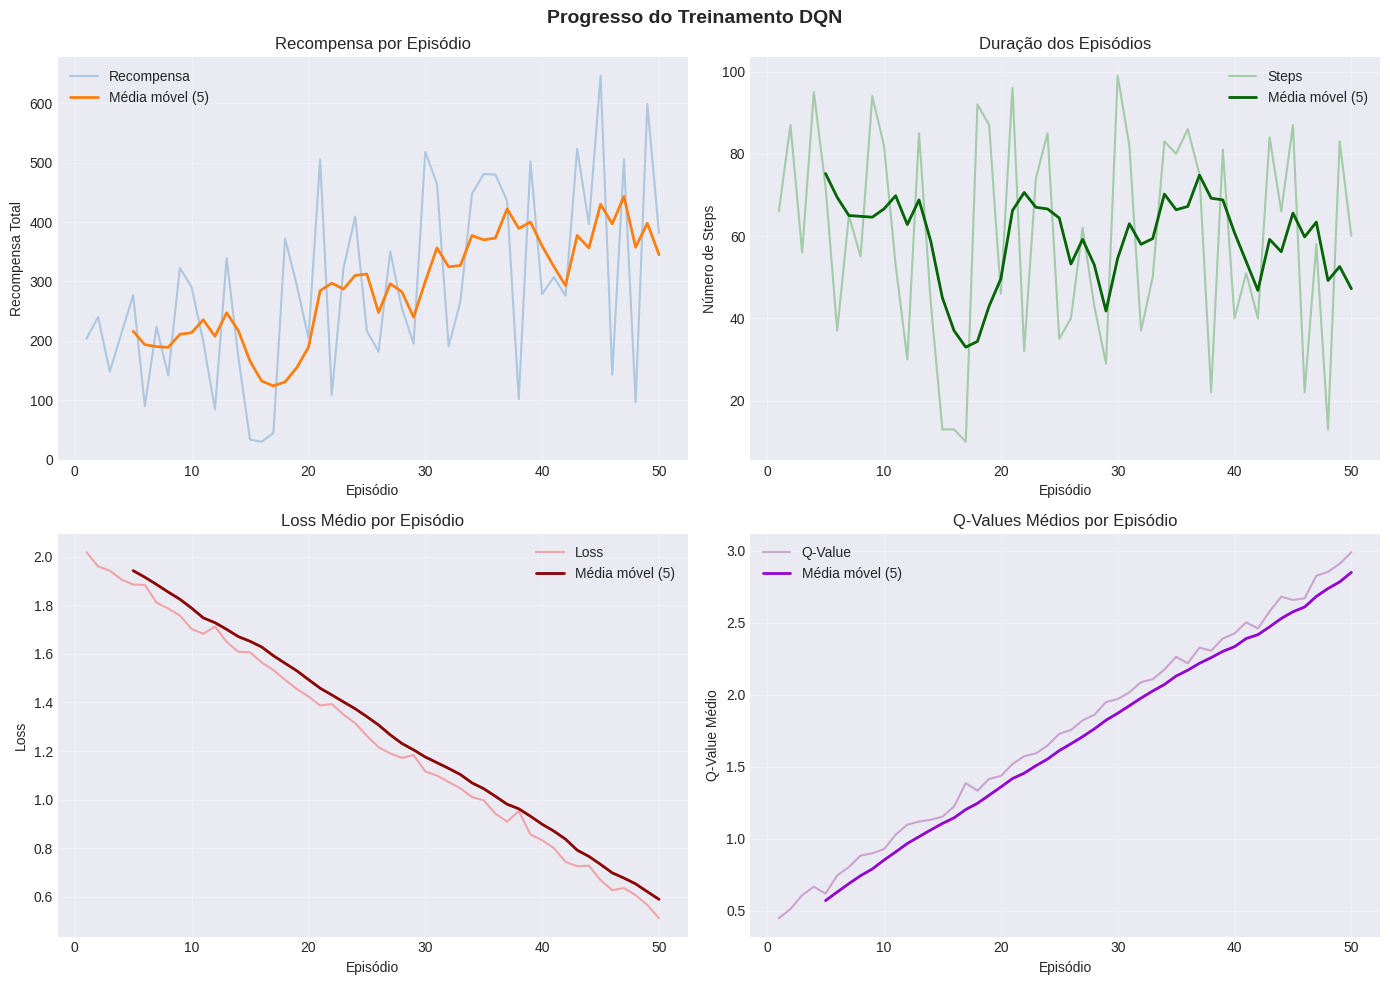

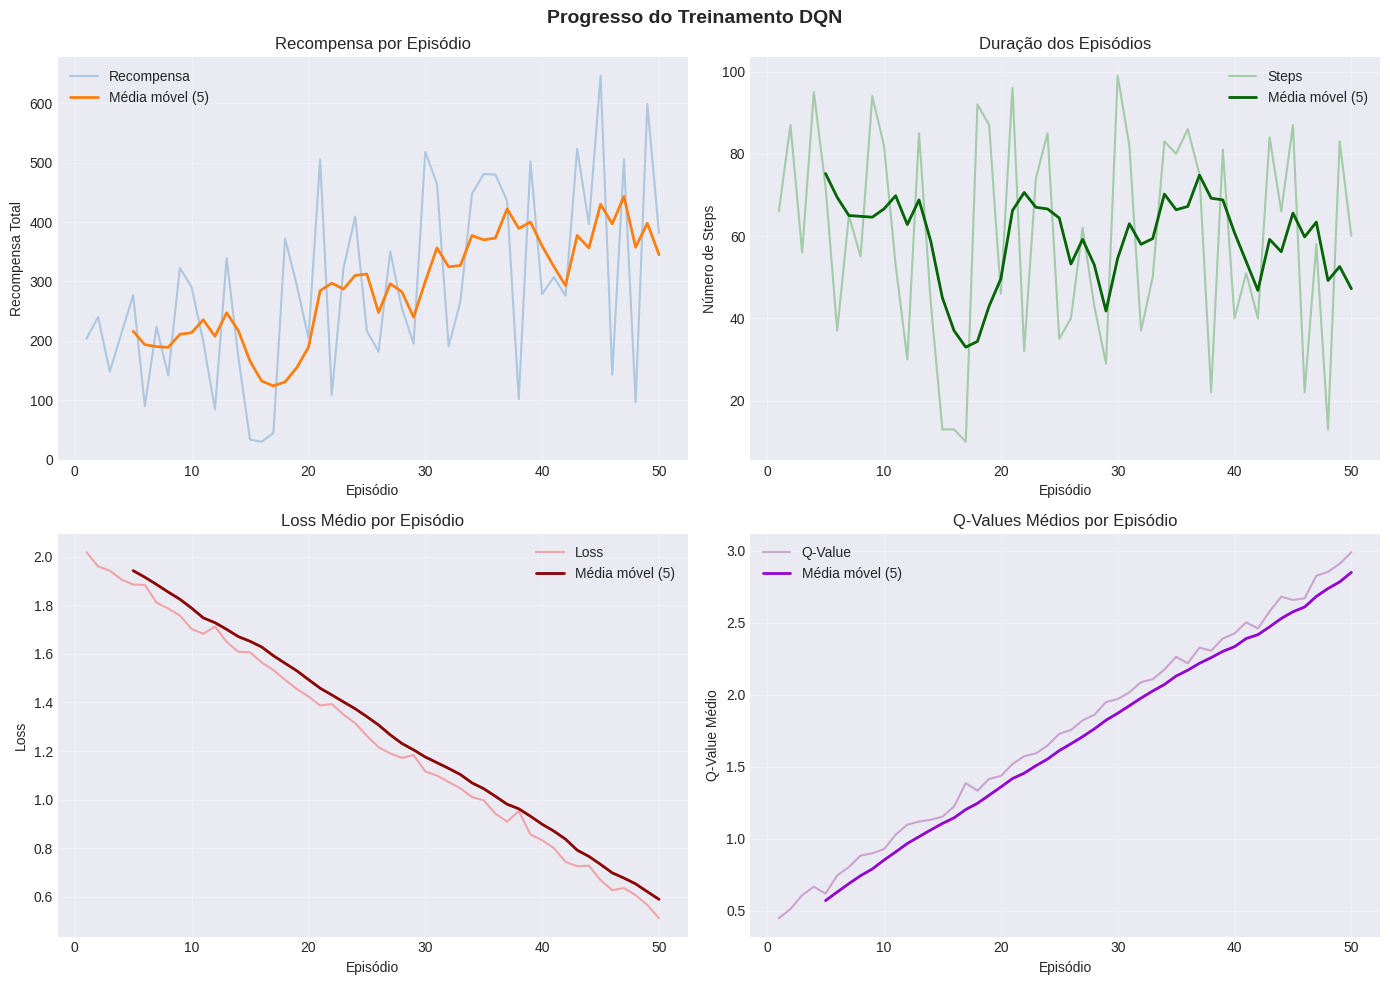

In [7]:
# Visualizar métricas
MetricsVisualizer.print_summary(metrics)
MetricsVisualizer.plot_training_progress(metrics, window=5)

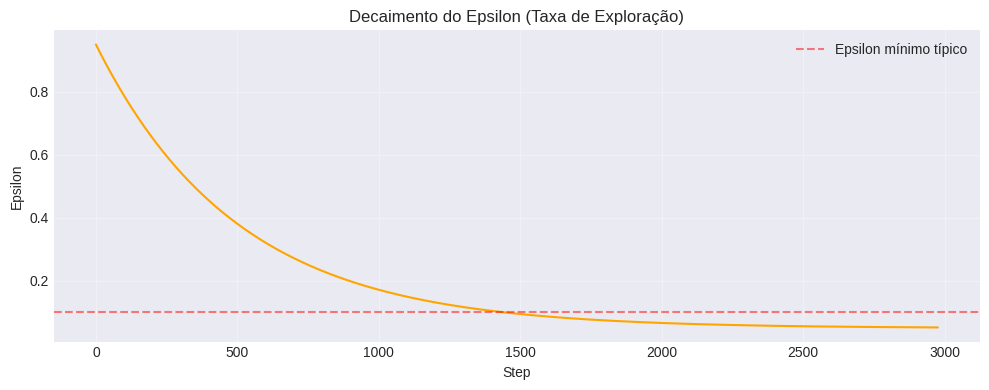

In [8]:
# Visualizar decaimento do epsilon
MetricsVisualizer.plot_epsilon_decay(metrics)

In [9]:
# Salvar métricas
metrics.save_metrics("demo_metrics.json")

✅ Métricas salvas em: ../output/metrics/demo_metrics.json


PosixPath('../output/metrics/demo_metrics.json')

---

## 3. Persistência do Modelo (Salvar/Carregar)

Sistema para salvar e carregar o estado do modelo, permitindo continuar o treinamento de onde parou.


In [10]:
class ModelCheckpoint:
    """Gerenciador de checkpoints para salvar e carregar modelos DQN."""

    def __init__(self, save_dir="../output/checkpoints"):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def save_checkpoint(
        self, model, optimizer, metrics, episode, steps_done, memory=None, filename=None
    ):
        """
        Salva um checkpoint completo do treinamento.

        Args:
            model: O modelo DQN
            optimizer: O otimizador
            metrics: Objeto TrainingMetrics
            episode: Número do episódio atual
            steps_done: Número total de steps
            memory: ReplayMemory (opcional, pode ser grande)
            filename: Nome do arquivo (opcional)
        """
        if filename is None:
            filename = (
                f"checkpoint_ep{episode}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pt"
            )

        checkpoint = {
            "episode": episode,
            "steps_done": steps_done,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": {
                "episode_rewards": metrics.episode_rewards,
                "episode_lengths": metrics.episode_lengths,
                "episode_losses": metrics.episode_losses,
                "episode_q_values": metrics.episode_q_values,
            },
            "timestamp": datetime.now().isoformat(),
        }

        # Salvar memória é opcional (pode ser muito grande)
        if memory is not None:
            checkpoint["memory_size"] = len(memory)
            # Não salvamos a memória completa por padrão (muito grande)

        filepath = self.save_dir / filename
        torch.save(checkpoint, filepath)

        print(f"\n✅ Checkpoint salvo: {filepath}")
        print(f"   - Episódio: {episode}")
        print(f"   - Steps: {steps_done}")
        print(f"   - Tamanho: {filepath.stat().st_size / 1024:.1f} KB")

        return filepath

    def load_checkpoint(self, filepath, model, optimizer, metrics=None):
        """
        Carrega um checkpoint e restaura o estado do treinamento.

        Returns:
            dict com episode e steps_done
        """
        checkpoint = torch.load(filepath, map_location=device)

        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        if metrics is not None and "metrics" in checkpoint:
            metrics.episode_rewards = checkpoint["metrics"].get("episode_rewards", [])
            metrics.episode_lengths = checkpoint["metrics"].get("episode_lengths", [])
            metrics.episode_losses = checkpoint["metrics"].get("episode_losses", [])
            metrics.episode_q_values = checkpoint["metrics"].get("episode_q_values", [])
            metrics.total_episodes = len(metrics.episode_rewards)

        print(f"\n✅ Checkpoint carregado: {filepath}")
        print(f"   - Episódio: {checkpoint['episode']}")
        print(f"   - Steps: {checkpoint['steps_done']}")
        print(f"   - Salvo em: {checkpoint.get('timestamp', 'N/A')}")

        return {
            "episode": checkpoint["episode"],
            "steps_done": checkpoint["steps_done"],
        }

    def list_checkpoints(self):
        """Lista todos os checkpoints disponíveis."""
        checkpoints = list(self.save_dir.glob("*.pt"))
        checkpoints.sort(key=lambda x: x.stat().st_mtime, reverse=True)

        print(f"\n📁 Checkpoints em {self.save_dir}:")
        print("-" * 60)

        if not checkpoints:
            print("   Nenhum checkpoint encontrado.")
            return []

        for cp in checkpoints:
            size = cp.stat().st_size / 1024
            mtime = datetime.fromtimestamp(cp.stat().st_mtime).strftime(
                "%Y-%m-%d %H:%M"
            )
            print(f"   {cp.name} ({size:.1f} KB) - {mtime}")

        return checkpoints

    def get_best_checkpoint(self, metric="reward"):
        """Encontra o melhor checkpoint baseado em uma métrica."""
        checkpoints = list(self.save_dir.glob("*.pt"))

        if not checkpoints:
            return None

        best_value = float("-inf")
        best_checkpoint = None

        for cp in checkpoints:
            data = torch.load(cp, map_location="cpu")
            if "metrics" in data and data["metrics"].get("episode_rewards"):
                # Usar média das últimas 10 recompensas
                rewards = data["metrics"]["episode_rewards"]
                avg_reward = np.mean(rewards[-10:]) if rewards else 0

                if avg_reward > best_value:
                    best_value = avg_reward
                    best_checkpoint = cp

        if best_checkpoint:
            print(f"\n🏆 Melhor checkpoint: {best_checkpoint.name}")
            print(f"   Recompensa média: {best_value:.2f}")

        return best_checkpoint

In [11]:
# Modelo DQN atual (do projeto)
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm2d(32)
        self.head = nn.Linear(448, 30)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        return self.head(x)


# Criar instâncias para demonstração
demo_model = DQN().to(device)
demo_optimizer = optim.RMSprop(demo_model.parameters())

print(f"Modelo criado no dispositivo: {device}")
print(f"Parâmetros totais: {sum(p.numel() for p in demo_model.parameters()):,}")

Modelo criado no dispositivo: cuda
Parâmetros totais: 53,310


In [12]:
# Demonstrar salvamento de checkpoint
checkpoint_manager = ModelCheckpoint()

# Salvar checkpoint de demonstração
checkpoint_manager.save_checkpoint(
    model=demo_model,
    optimizer=demo_optimizer,
    metrics=metrics,  # Métricas da simulação anterior
    episode=50,
    steps_done=metrics.total_steps,
)


✅ Checkpoint salvo: ../output/checkpoints/checkpoint_ep50_20251130_230939.pt
   - Episódio: 50
   - Steps: 2977
   - Tamanho: 224.8 KB


PosixPath('../output/checkpoints/checkpoint_ep50_20251130_230939.pt')

In [13]:
# Listar checkpoints disponíveis
checkpoint_manager.list_checkpoints()


📁 Checkpoints em ../output/checkpoints:
------------------------------------------------------------
   checkpoint_ep50_20251130_230939.pt (224.8 KB) - 2025-11-30 23:09
   checkpoint_ep50_20251130_223631.pt (224.8 KB) - 2025-11-30 22:36


[PosixPath('../output/checkpoints/checkpoint_ep50_20251130_230939.pt'),
 PosixPath('../output/checkpoints/checkpoint_ep50_20251130_223631.pt')]

---

## 4. Análise de Melhorias Potenciais

Análise detalhada do modelo atual e sugestões de melhorias.


In [14]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    ANÁLISE DO MODELO DQN ATUAL                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

📋 ARQUITETURA ATUAL:
────────────────────────────────────────────────────────────────────────────────
• 3 camadas convolucionais (16 → 32 → 32 filtros)
• Batch Normalization após cada convolução
• 1 camada fully-connected (448 → 30 ações)
• Ativação: ReLU
• Otimizador: RMSprop
• Replay Memory: 10.000 transições
• Batch Size: 256

📊 HIPERPARÂMETROS:
────────────────────────────────────────────────────────────────────────────────
• GAMMA (desconto): 0.999 (muito alto, foco em recompensas futuras)
• EPS_START: 0.9 (90% exploração inicial)
• EPS_END: 0.05 (5% exploração final)
• EPS_DECAY: 500 (decaimento rápido)
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    ANÁLISE DO MODELO DQN ATUAL                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

📋 ARQUITETURA ATUAL:
────────────────────────────────────────────────────────────────────────────────
• 3 camadas convolucionais (16 → 32 → 32 filtros)
• Batch Normalization após cada convolução
• 1 camada fully-connected (448 → 30 ações)
• Ativação: ReLU
• Otimizador: RMSprop
• Replay Memory: 10.000 transições
• Batch Size: 256

📊 HIPERPARÂMETROS:
────────────────────────────────────────────────────────────────────────────────
• GAMMA (desconto): 0.999 (muito alto, foco em recompensas futuras)
• EPS_START: 0.9 (90% exploração inicial)
• EPS_END: 0.05 (5% exploração final)
• EPS_DECAY: 500 (decaimento rápido)



In [15]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    MELHORIAS RECOMENDADAS                                    ║
╚══════════════════════════════════════════════════════════════════════════════╝

🔴 PRIORIDADE ALTA:
────────────────────────────────────────────────────────────────────────────────

1. DOUBLE DQN
   Problema: DQN padrão superestima Q-values
   Solução: Usar duas redes (policy e target) para separar seleção e avaliação
   Impacto: Treinamento mais estável, convergência melhor

2. TARGET NETWORK
   Problema: Atualizações instáveis (target muda a cada step)
   Solução: Copiar pesos para target network periodicamente
   Impacto: Reduz oscilações, melhora convergência

3. DUELING DQN
   Problema: Nem todas as ações são relevantes em todos os estados
   Solução: Separar estimativa de valor do estado e vantagem da ação
   Impacto: Melhor generalização, especialmente com muitas ações

🟡 PRIORIDADE MÉDIA:
────────────────────────────────────────────────────────────────────────────────

4. PRIORITIZED EXPERIENCE REPLAY
   Problema: Amostragem uniforme desperdiça experiências importantes
   Solução: Priorizar transições com alto TD-error
   Impacto: Aprendizado mais eficiente, menos amostras necessárias

5. NOISY NETWORKS
   Problema: Epsilon-greedy não é ideal para exploração
   Solução: Adicionar ruído aos pesos da rede
   Impacto: Exploração mais inteligente e adaptativa

6. N-STEP RETURNS
   Problema: TD(1) tem alto bias
   Solução: Usar retornos de múltiplos steps
   Impacto: Melhor propagação de recompensas, bias-variance tradeoff

🟢 PRIORIDADE BAIXA (OTIMIZAÇÕES):
────────────────────────────────────────────────────────────────────────────────

7. AJUSTES DE HIPERPARÂMETROS:
   • GAMMA: Reduzir para 0.99 (mais foco no curto prazo)
   • EPS_DECAY: Aumentar para 1000-2000 (exploração mais longa)
   • Learning Rate: Adicionar scheduler (reduzir ao longo do tempo)

8. ARQUITETURA DA REDE:
   • Usar mais camadas convolucionais para imagens maiores
   • Adicionar Dropout para regularização
   • Considerar ResNet ou EfficientNet como backbone

9. GRADIENT CLIPPING:
   • Já implementado (clamp_(-1, 1)), mas pode ser ajustado
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    MELHORIAS RECOMENDADAS                                    ║
╚══════════════════════════════════════════════════════════════════════════════╝

🔴 PRIORIDADE ALTA:
────────────────────────────────────────────────────────────────────────────────

1. DOUBLE DQN
   Problema: DQN padrão superestima Q-values
   Solução: Usar duas redes (policy e target) para separar seleção e avaliação
   Impacto: Treinamento mais estável, convergência melhor

2. TARGET NETWORK
   Problema: Atualizações instáveis (target muda a cada step)
   Solução: Copiar pesos para target network periodicamente
   Impacto: Reduz oscilações, melhora convergência

3. DUELING DQN
   Problema: Nem todas as ações são relevantes em todos os estados
   Solução: Separar estimativa de valor do estado e vantagem da ação
   Impacto: Melhor generalização, especialmente com muitas ações

🟡 PRIORIDADE MÉDIA:
────────────────────────────

In [16]:
# Implementação de Double DQN com Target Network


class ImprovedDQN(nn.Module):
    """DQN melhorado com arquitetura Dueling."""

    def __init__(self, num_actions=30):
        super(ImprovedDQN, self).__init__()

        # Feature extraction (convolutional layers)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )

        # Calcular tamanho do output das convoluções
        # (depende do tamanho da imagem de entrada)
        self.feature_size = 64 * 7 * 7  # Para imagem 84x84

        # Dueling architecture: separar Value e Advantage
        # Stream de Valor (V)
        self.value_stream = nn.Sequential(
            nn.Linear(self.feature_size, 512),
            nn.ReLU(),
            nn.Linear(512, 1),  # Valor do estado
        )

        # Stream de Vantagem (A)
        self.advantage_stream = nn.Sequential(
            nn.Linear(self.feature_size, 512),
            nn.ReLU(),
            nn.Linear(512, num_actions),  # Vantagem de cada ação
        )

    def forward(self, x):
        features = self.features(x)
        features = features.view(features.size(0), -1)

        # Dueling: Q(s,a) = V(s) + (A(s,a) - mean(A(s,:)))
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)

        # Combinar: subtrair média das vantagens para estabilidade
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))

        return q_values


class DQNAgent:
    """Agente DQN completo com Double DQN e Target Network."""

    def __init__(self, num_actions=30, device="cpu"):
        self.device = device
        self.num_actions = num_actions

        # Redes: policy e target
        self.policy_net = ImprovedDQN(num_actions).to(device)
        self.target_net = ImprovedDQN(num_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()  # Target network em modo avaliação

        # Otimizador com learning rate ajustável
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-4)
        self.scheduler = optim.lr_scheduler.StepLR(
            self.optimizer, step_size=10000, gamma=0.9
        )

        # Hiperparâmetros
        self.gamma = 0.99
        self.eps_start = 1.0
        self.eps_end = 0.01
        self.eps_decay = 10000
        self.target_update = 1000  # Atualizar target a cada N steps

        self.steps_done = 0

    def select_action(self, state, available_actions):
        """Seleciona ação usando epsilon-greedy."""
        # Calcular epsilon atual
        eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * math.exp(
            -1.0 * self.steps_done / self.eps_decay
        )
        self.steps_done += 1

        if random.random() > eps_threshold:
            # Exploração: usar a rede
            with torch.no_grad():
                q_values = self.policy_net(state)
                # Mascarar ações não disponíveis
                q_values = q_values[0, : len(available_actions)]
                return q_values.argmax().item(), eps_threshold
        else:
            # Exploração: ação aleatória
            return random.randrange(len(available_actions)), eps_threshold

    def optimize(self, memory, batch_size=128):
        """Otimiza o modelo usando Double DQN."""
        if len(memory) < batch_size:
            return None

        # Amostrar batch
        transitions = memory.sample(batch_size)
        batch = list(zip(*transitions))

        state_batch = torch.cat(batch[0])
        action_batch = torch.tensor(batch[1], device=self.device).unsqueeze(1)
        reward_batch = torch.tensor(batch[3], device=self.device, dtype=torch.float)

        # Máscara para estados não-terminais
        non_final_mask = torch.tensor(
            [s is not None for s in batch[2]], device=self.device, dtype=torch.bool
        )
        non_final_next_states = torch.cat([s for s in batch[2] if s is not None])

        # Q(s, a) da policy network
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)

        # Double DQN: usar policy_net para selecionar ação, target_net para avaliar
        next_state_values = torch.zeros(batch_size, device=self.device)
        with torch.no_grad():
            # Selecionar melhores ações com policy_net
            next_actions = self.policy_net(non_final_next_states).argmax(1).unsqueeze(1)
            # Avaliar essas ações com target_net
            next_state_values[non_final_mask] = (
                self.target_net(non_final_next_states).gather(1, next_actions).squeeze()
            )

        # Target: r + gamma * Q_target(s', argmax_a Q_policy(s', a))
        expected_state_action_values = reward_batch + (self.gamma * next_state_values)

        # Huber loss (smooth L1)
        loss = F.smooth_l1_loss(
            state_action_values.squeeze(), expected_state_action_values
        )

        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10)

        self.optimizer.step()
        self.scheduler.step()

        # Atualizar target network periodicamente
        if self.steps_done % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()


print("✅ Classes ImprovedDQN e DQNAgent definidas com sucesso!")

✅ Classes ImprovedDQN e DQNAgent definidas com sucesso!


In [17]:
# Comparação de arquiteturas


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


original_dqn = DQN()
improved_dqn = ImprovedDQN()

print("\n📊 Comparação de Arquiteturas:")
print("=" * 50)
print(f"\nDQN Original:")
print(f"  Parâmetros treináveis: {count_parameters(original_dqn):,}")
print(f"\nDQN Melhorado (Dueling):")
print(f"  Parâmetros treináveis: {count_parameters(improved_dqn):,}")


📊 Comparação de Arquiteturas:

DQN Original:
  Parâmetros treináveis: 53,310

DQN Melhorado (Dueling):
  Parâmetros treináveis: 3,304,127


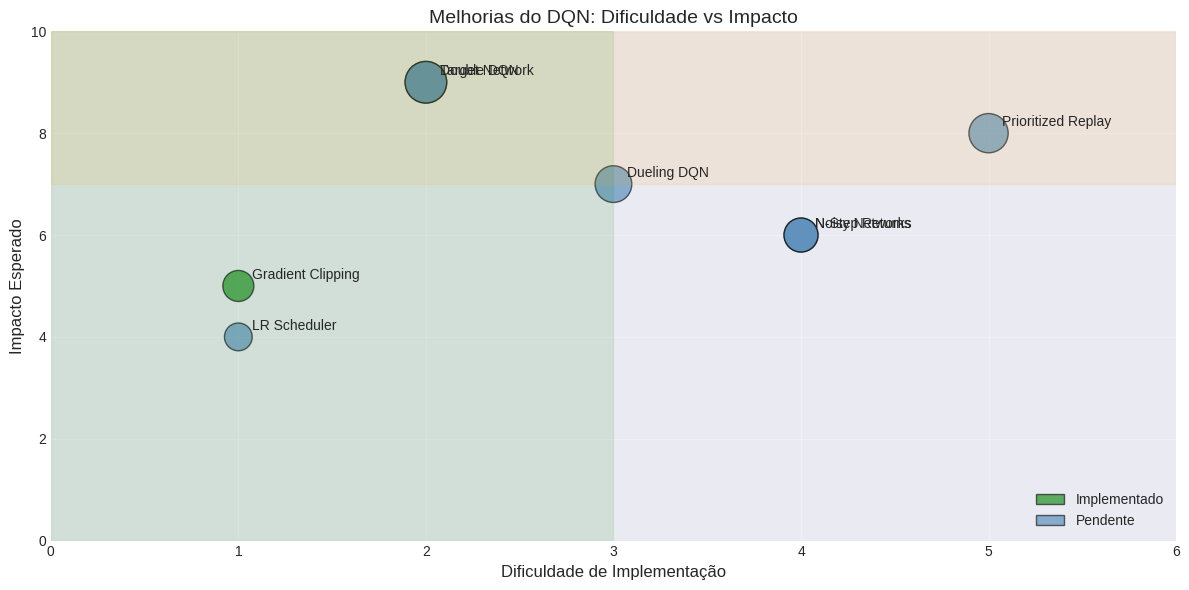


💡 Recomendação: Priorize melhorias no quadrante superior esquerdo
   (baixa dificuldade + alto impacto)


In [18]:
# Visualização das melhorias

improvements = {
    "Double DQN": {"dificuldade": 2, "impacto": 9, "implementado": False},
    "Target Network": {"dificuldade": 2, "impacto": 9, "implementado": False},
    "Dueling DQN": {"dificuldade": 3, "impacto": 7, "implementado": False},
    "Prioritized Replay": {"dificuldade": 5, "impacto": 8, "implementado": False},
    "Noisy Networks": {"dificuldade": 4, "impacto": 6, "implementado": False},
    "N-Step Returns": {"dificuldade": 4, "impacto": 6, "implementado": False},
    "LR Scheduler": {"dificuldade": 1, "impacto": 4, "implementado": False},
    "Gradient Clipping": {"dificuldade": 1, "impacto": 5, "implementado": True},
}

fig, ax = plt.subplots(figsize=(12, 6))

names = list(improvements.keys())
dificuldade = [improvements[n]["dificuldade"] for n in names]
impacto = [improvements[n]["impacto"] for n in names]
implementado = [improvements[n]["implementado"] for n in names]

colors = ["green" if imp else "steelblue" for imp in implementado]
sizes = [i * 100 for i in impacto]

scatter = ax.scatter(
    dificuldade, impacto, s=sizes, c=colors, alpha=0.6, edgecolors="black"
)

for i, name in enumerate(names):
    ax.annotate(
        name,
        (dificuldade[i], impacto[i]),
        xytext=(10, 5),
        textcoords="offset points",
        fontsize=10,
    )

ax.set_xlabel("Dificuldade de Implementação", fontsize=12)
ax.set_ylabel("Impacto Esperado", fontsize=12)
ax.set_title("Melhorias do DQN: Dificuldade vs Impacto", fontsize=14)
ax.set_xlim(0, 6)
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.3)

# Legenda
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="green", alpha=0.6, edgecolor="black", label="Implementado"),
    Patch(facecolor="steelblue", alpha=0.6, edgecolor="black", label="Pendente"),
]
ax.legend(handles=legend_elements, loc="lower right")

# Região de prioridade
ax.axvspan(0, 3, alpha=0.1, color="green", label="Baixa dificuldade")
ax.axhspan(7, 10, alpha=0.1, color="orange", label="Alto impacto")

plt.tight_layout()
plt.show()

print("\n💡 Recomendação: Priorize melhorias no quadrante superior esquerdo")
print("   (baixa dificuldade + alto impacto)")

---

## 5. Código de Integração

Código pronto para integrar as melhorias no projeto principal.


In [19]:
# Exemplo de como integrar as métricas no loop de treinamento principal

example_code = """
# Em main.py ou no loop de treinamento:

from agent.metrics import TrainingMetrics, MetricsVisualizer
from agent.checkpoint import ModelCheckpoint

# Inicializar
metrics = TrainingMetrics()
checkpoint_mgr = ModelCheckpoint()

# No loop de treinamento:
for episode in range(num_episodes):
    state = env.reset()
    
    for step in range(max_steps):
        action = agent.select_action(state, actions)
        next_state, reward, done, info = env.step(action)
        
        # Otimizar e obter loss
        loss = agent.optimize(memory)
        
        # Registrar métricas
        metrics.log_step(
            reward=reward,
            loss=loss,
            q_value=agent.get_q_value(state, action),
            epsilon=agent.epsilon
        )
        
        if done:
            break
    
    # Finalizar episódio
    metrics.end_episode()
    
    # Checkpoint periódico
    if episode % 100 == 0:
        checkpoint_mgr.save_checkpoint(
            model=agent.policy_net,
            optimizer=agent.optimizer,
            metrics=metrics,
            episode=episode,
            steps_done=agent.steps_done
        )

# Ao final
metrics.save_metrics()
MetricsVisualizer.plot_training_progress(metrics)
"""

print(example_code)


# Em main.py ou no loop de treinamento:

from agent.metrics import TrainingMetrics, MetricsVisualizer
from agent.checkpoint import ModelCheckpoint

# Inicializar
metrics = TrainingMetrics()
checkpoint_mgr = ModelCheckpoint()

# No loop de treinamento:
for episode in range(num_episodes):
    state = env.reset()

    for step in range(max_steps):
        action = agent.select_action(state, actions)
        next_state, reward, done, info = env.step(action)

        # Otimizar e obter loss
        loss = agent.optimize(memory)

        # Registrar métricas
        metrics.log_step(
            reward=reward,
            loss=loss,
            q_value=agent.get_q_value(state, action),
            epsilon=agent.epsilon
        )

        if done:
            break

    # Finalizar episódio
    metrics.end_episode()

    # Checkpoint periódico
    if episode % 100 == 0:
        checkpoint_mgr.save_checkpoint(
            model=agent.policy_net,
            optimizer=agent.optimizer,
        

---

## Resumo e Próximos Passos

### O que foi implementado neste notebook:

1. ✅ Sistema de verificação GPU/CPU com benchmark
2. ✅ Sistema de métricas (TrainingMetrics) com persistência
3. ✅ Visualizador de métricas (MetricsVisualizer)
4. ✅ Sistema de checkpoints (ModelCheckpoint)
5. ✅ Implementação de Double DQN com Target Network
6. ✅ Implementação de Dueling DQN
7. ✅ Análise detalhada de melhorias

### Próximos passos recomendados:

1. Integrar TrainingMetrics no loop principal (main.py)
2. Substituir DQN atual pelo ImprovedDQN
3. Adicionar checkpoints automáticos
4. Implementar Prioritized Experience Replay
5. Ajustar hiperparâmetros baseado nas métricas coletadas
